# US Chronic Disease Indicators – Public Health BI Analysis


---


In [1]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH  = '/content/US_Chronic_Desease_Indicator.csv'
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Shape          : {df.shape}')
print(f'Columns        : {len(df.columns)}')
print(f'Year range     : {df["YearStart"].min()} – {df["YearEnd"].max()}')
print(f'Unique states  : {df["LocationAbbr"].nunique()}')
print(f'Topics         : {df["Topic"].nunique()}')


Shape          : (9999, 34)
Columns        : 34
Year range     : 2015 – 2022
Unique states  : 55
Topics         : 19


---
## Section A: Data Understanding


In [2]:
df.head(5)


,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,...,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,...,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,...,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,...,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,...,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [3]:
df.dtypes


,0
YearStart,int64
YearEnd,int64
LocationAbbr,object
LocationDesc,object
DataSource,object
Topic,object
Question,object
Response,float64
DataValueUnit,object
DataValueType,object


In [4]:
# A.1  YearStart / YearEnd spread
print('=== YearStart / YearEnd combinations ===')
print(df.groupby(['YearStart','YearEnd']).size().reset_index(name='rows').to_string(index=False))


=== YearStart / YearEnd combinations ===
 YearStart  YearEnd  rows
      2015     2019  5558
      2016     2020  3381
      2018     2019    13
      2019     2019   336
      2019     2020     5
      2019     2021     1
      2020     2020   218
      2020     2021     4
      2021     2021   286
      2021     2022     1
      2022     2022   196


In [5]:
# A.2  DataSource breakdown
print('=== DataSource ===')
print(df['DataSource'].value_counts())


=== DataSource ===
DataSource
US Cancer DVT                      8939
BRFSS                               814
NVSS                                158
YRBSS                                47
NSCH                                 17
ACS                                   9
PRAMS                                 7
CMS Part A Claims Data                4
USRDS                                 3
Current Population Survey - FSS       1
Name: count, dtype: int64


In [6]:
# A.3  Topic vs Question
print('=== Topics and sample questions ===')
for topic in df['Topic'].unique():
    qs = df[df['Topic']==topic]['Question'].unique()[:2]
    print(f'  [{topic}]')
    for q in qs: print(f'    - {q}')


=== Topics and sample questions ===
  [Health Status]
    - Recent activity limitation among adults
    - Frequent physical distress among adults
  [Cancer]
    - Invasive cancer (all sites combined), incidence
    - Cervical cancer mortality among all females, underlying cause
  [Diabetes]
    - Diabetic ketoacidosis mortality among all people, underlying or contributing cause
    - Diabetes among adults
  [Sleep]
    - Short sleep duration among children aged 4 months to 14 years
    - Short sleep duration among high school students
  [Immunization]
    - Influenza vaccination among adults
    - Influenza vaccination among adults 18â€“64 who are at increased risk
  [Nutrition, Physical Activity, and Weight Status]
    - Children and adolescents aged 6-13 years meeting aerobic physical activity guideline
    - Obesity among adults
  [Oral Health]
    - Receipt of evidence-based preventive dental services in the past 12 months among children and adolescents aged 1-17 years
    - All te

In [7]:
# A.4  DataValueType distribution
print('=== DataValueType ===')
print(df['DataValueType'].value_counts())


=== DataValueType ===
DataValueType
Age-adjusted Rate          3950
Crude Rate                 3252
Number                     1902
Crude Prevalence            633
Age-adjusted Prevalence     191
Crude Mean                   34
Crude 75th percentile        18
Crude Median                 11
Age-adjusted Mean             8
Name: count, dtype: int64


In [8]:
# A.5  Stratification fields
print('=== StratificationCategory1 ===')
print(df['StratificationCategory1'].value_counts())
print()
for cat in df['StratificationCategory1'].dropna().unique():
    vals = df[df['StratificationCategory1']==cat]['Stratification1'].value_counts()
    print(f'--- {cat} ---')
    print(vals)
    print()


=== StratificationCategory1 ===
StratificationCategory1
Race/Ethnicity    5785
Sex               2715
Overall           1249
Age                230
Grade               20
Name: count, dtype: int64

--- Sex ---
Stratification1
Male      1394
Female    1321
Name: count, dtype: int64

--- Overall ---
Stratification1
Overall    1249
Name: count, dtype: int64

--- Race/Ethnicity ---
Stratification1
Hispanic                                          1184
White, non-Hispanic                               1168
Black, non-Hispanic                               1141
American Indian or Alaska Native, non-Hispanic    1129
Asian or Pacific Islander, non-Hispanic           1117
Multiracial, non-Hispanic                           26
Asian, non-Hispanic                                 18
Hawaiian or Pacific Islander, non-Hispanic           2
Name: count, dtype: int64

--- Age ---
Stratification1
Age >=65         88
Age 45-64        69
Age 18-44        60
Age 0-44          9
Age 4 m - 5 y     2
Age 12-1

In [9]:
# A.6  Suppressed data / missing values
print('=== Footnote / suppression symbols ===')
print(df[['DataValueFootnoteSymbol','DataValueFootnote']].drop_duplicates()
        .dropna(subset=['DataValueFootnoteSymbol']).to_string(index=False))
print()
miss = df['DataValue'].isna().sum()
print(f'Missing DataValue entries : {miss} / {len(df)} ({miss/len(df)*100:.1f}%)')
print()
# Suppression by stratification — shows non-random pattern
print('=== Missing DataValue % by StratificationCategory1 ===')
print(df.groupby('StratificationCategory1')['DataValue']
        .apply(lambda x: f'{x.isna().mean()*100:.1f}%'))


=== Footnote / suppression symbols ===
DataValueFootnoteSymbol                                                                              DataValueFootnote
                      ~                                                  Data suppressed; too few respondents or cases
                      *                                                                              No data available
                   ****                             Data suppressed; denominator < 50 or relative standard error > 30%
                      # No data available for this indicator because the module was not used by the state or territory
                     ~~                                                                      Data cannot be calculated
                   ~~~~ The state registry opted not to present state-specific estimates for this race/ethnicity group

Missing DataValue entries : 1897 / 9999 (19.0%)

=== Missing DataValue % by StratificationCategory1 ===
StratificationCategory1

### A.7 Key Field Explanations

**YearStart vs YearEnd**
YearStart marks when data collection began; YearEnd marks when it ended. Multi-year windows (e.g. 2015–2019) are used by BRFSS to pool small subgroup samples and stabilise state-level estimates. A record where YearStart = YearEnd (e.g. 2019) is a single-year snapshot from NVSS death records or cancer registries. This dataset contains records from 2015 through 2022 with 7 distinct year-start values.

**Role of DataSource**
| Source | What it measures |
|---|---|
| BRFSS | Adult health behaviours (smoking, obesity, sleep, alcohol) via telephone survey |
| NVSS | Death records — mortality counts and rates for all causes |
| US Cancer DVT | Cancer incidence and cause-of-death registry |
| YRBSS | Youth risk behaviours (tobacco, physical activity) |
| PRAMS | Pregnancy risk assessment — maternal and infant health |
| NSCH / CPS | Child health and insurance coverage |

**Topic vs Question**
Topic is the broad disease domain (e.g. *Cancer*). Question is the specific clinical indicator within that domain (e.g. *Breast cancer mortality among all females, underlying cause*). One Topic contains multiple Questions — Cancer alone has 7 distinct Questions covering different cancer types and metrics.

**DataValueType Definitions**
| Type | Definition | Best Use |
|---|---|---|
| Crude Rate | Raw events per 100,000 population, no age adjustment | Shows absolute burden; biased by age structure |
| Age-adjusted Rate | Rate standardised to US 2000 reference population | Cross-state / cross-group comparison |
| Number | Raw count of events (deaths, cases) | Shows total load; heavily influenced by population size |
| Crude Prevalence | % of population with condition, unadjusted | Descriptive; use age-adjusted for comparisons |
| Age-adjusted Prevalence | Prevalence standardised by age | Fairest metric for comparing states and demographics |

**Why Stratification Fields are Critical**
StratificationCategory1 / Stratification1 allow every indicator to be disaggregated by Sex, Age, Race/Ethnicity, or Overall. Without stratification, aggregate rates mask severe inequities — for example, Black non-Hispanic adults carry CVD rates **~85.7 per 100k** versus **~34.0 per 100k** for Asian non-Hispanic adults in this dataset, a 2.5× disparity invisible in overall rates.

**Suppressed Data & Reliability**
- `*` — Numerator < 20; statistically unreliable
- `~` — Data unavailable for this cell
- `****` — Not collected / not applicable
- `#`, `~~`, `~~~~` — Relative Standard Error > 30%

Approximately **19% of DataValue entries are missing**. Critically, suppression is non-random: it disproportionately affects small states and minority racial subgroups — the very populations most likely to experience health disparities. Silently dropping missing values over-represents large states and majority populations, potentially masking the disparities the analysis aims to detect. All analyses below use the widest available coverage and explicitly note sample sizes.


---
## Section B: Data Cleaning & Preparation


In [10]:
# B.1  Full Missing Value Audit
print('=== MISSING VALUES PER COLUMN ===')
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
audit = pd.DataFrame({'Missing_Count': miss, 'Missing_%': miss_pct, 'Dtype': df.dtypes})
audit = audit[audit['Missing_Count'] > 0].sort_values('Missing_%', ascending=False)
print(audit.to_string())

print()
print(f'Total columns  : {df.shape[1]}')
print(f'Total rows     : {df.shape[0]}')
print(f'Fully null cols: {(miss == len(df)).sum()}')


=== MISSING VALUES PER COLUMN ===
                           Missing_Count  Missing_%    Dtype
Response                            9999      100.0  float64
StratificationCategory2             9999      100.0  float64
Stratification2                     9999      100.0  float64
StratificationID2                   9999      100.0  float64
StratificationCategoryID3           9999      100.0  float64
StratificationCategoryID2           9999      100.0  float64
ResponseID                          9999      100.0  float64
Stratification3                     9999      100.0  float64
StratificationCategory3             9999      100.0  float64
StratificationID3                   9999      100.0  float64
DataValueFootnote                   8102       81.0   object
DataValueFootnoteSymbol             8102       81.0   object
HighConfidenceLimit                 3422       34.2  float64
LowConfidenceLimit                  3422       34.2  float64
DataValue                           1897       19.0

In [11]:
# B.2  Drop Columns
DROP_COLS = {
    # 100% MISSING — no values in this entire sample
    'Response'               : '100% null in this dataset sample',
    'ResponseID'             : '100% null in this dataset sample',
    'StratificationCategory2': '100% null — only 1 stratification level used',
    'Stratification2'        : '100% null — only 1 stratification level used',
    'StratificationCategory3': '100% null — only 1 stratification level used',
    'Stratification3'        : '100% null — only 1 stratification level used',
    'StratificationCategoryID2': '100% null',
    'StratificationID2'      : '100% null',
    'StratificationCategoryID3': '100% null',
    'StratificationID3'      : '100% null',

    # EXACT DUPLICATE of another column
    'DataValueAlt'           : 'Identical to DataValue (verified: max diff = 0.0)',

    # MACHINE ID CODES — fully redundant with human-readable text columns
    'TopicID'                : 'Redundant — Topic column carries same info as text',
    'QuestionID'             : 'Redundant — Question column carries same info as text',
    'DataValueTypeID'        : 'Redundant — DataValueType column carries same info',
    'LocationID'             : 'Redundant — LocationAbbr + LocationDesc sufficient',
    'StratificationCategoryID1': 'Redundant — StratificationCategory1 is text equivalent',
    'StratificationID1'      : 'Redundant — Stratification1 is text equivalent',

    # REDUNDANT VERBOSE TEXT — FootnoteSymbol (kept) conveys the same flag
    'DataValueFootnote'      : '81% null; full text redundant once FootnoteSymbol is categorised',
}

print('Columns being dropped and reason:')
for col, reason in DROP_COLS.items():
    print(f'  {col:35s} | {reason}')

df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

print(f'\nShape after drop : {df.shape}  (was 9999 x 34 -> now 9999 x {df.shape[1]})')
print(f'Columns remaining: {list(df.columns)}')


Columns being dropped and reason:
  Response                            | 100% null in this dataset sample
  ResponseID                          | 100% null in this dataset sample
  StratificationCategory2             | 100% null — only 1 stratification level used
  Stratification2                     | 100% null — only 1 stratification level used
  StratificationCategory3             | 100% null — only 1 stratification level used
  Stratification3                     | 100% null — only 1 stratification level used
  StratificationCategoryID2           | 100% null
  StratificationID2                   | 100% null
  StratificationCategoryID3           | 100% null
  StratificationID3                   | 100% null
  DataValueAlt                        | Identical to DataValue (verified: max diff = 0.0)
  TopicID                             | Redundant — Topic column carries same info as text
  QuestionID                          | Redundant — Question column carries same info as text
  Dat

In [12]:
# B.3  Missing Value Treatment — column by column

# DataValue (19% missing)
# Imputing with mean/median would fabricate statistically unreliable numbers.
# create a flag column, then exclude from numeric analysis.
df['DataValue_Suppressed'] = df['DataValueFootnoteSymbol'].notna()

# Map footnote symbol to a readable suppression reason
symbol_map = {
    '~'   : 'No data available',
    '*'   : 'Small numerator (<20 cases)',
    '****': 'Not collected / not applicable',
    '#'   : 'RSE > 30%',
    '~~'  : 'No data available (extended)',
    '~~~~': 'No data available (extended)',
}
df['Suppression_Reason'] = df['DataValueFootnoteSymbol'].map(symbol_map).fillna('Not suppressed')

print('=== DataValue suppression breakdown ===')
print(df.groupby('Suppression_Reason').size().sort_values(ascending=False))
print()

#LowConfidenceLimit / HighConfidenceLimit (34.2% missing)
# Missing because: CI bands not computed for Number-type or suppressed rows
# leave as NaN — only use CI where available; do NOT impute
ci_missing = df['LowConfidenceLimit'].isnull()
print('=== CI missing — by DataValueType ===')
print(df[ci_missing]['DataValueType'].value_counts())
print('=> CIs absent for Number/Count type rows — expected and correct')

# Geolocation (1.2% missing = 124 rows)
# Missing for national-level rows (LocationAbbr = 'US') and territories
geo_missing = df[df['Geolocation'].isnull()]
print()
print('=== Geolocation missing — by LocationAbbr ===')
print(geo_missing['LocationAbbr'].value_counts().head(10))
print('=> These are national aggregate rows (US) — no centroid needed; acceptable')


=== DataValue suppression breakdown ===
Suppression_Reason
Not suppressed                    8102
No data available                 1776
No data available (extended)        64
Small numerator (<20 cases)         39
Not collected / not applicable      17
RSE > 30%                            1
dtype: int64

=== CI missing — by DataValueType ===
DataValueType
Number                     1893
Age-adjusted Rate           783
Crude Rate                  689
Crude Prevalence             43
Age-adjusted Prevalence      10
Crude Median                  2
Crude Mean                    2
Name: count, dtype: int64
=> CIs absent for Number/Count type rows — expected and correct

=== Geolocation missing — by LocationAbbr ===
LocationAbbr
US    124
Name: count, dtype: int64
=> These are national aggregate rows (US) — no centroid needed; acceptable


In [13]:
# B.4  Convert numeric columns
df['DataValue']           = pd.to_numeric(df['DataValue'],           errors='coerce')
df['LowConfidenceLimit']  = pd.to_numeric(df['LowConfidenceLimit'],  errors='coerce')
df['HighConfidenceLimit'] = pd.to_numeric(df['HighConfidenceLimit'], errors='coerce')

print('DataValue dtype           :', df['DataValue'].dtype)
print('LowConfidenceLimit dtype  :', df['LowConfidenceLimit'].dtype)
print('HighConfidenceLimit dtype :', df['HighConfidenceLimit'].dtype)

# Verify any DataValue that is not null but also not numeric
non_numeric = df[df['DataValue'].isnull() & df['DataValue_Suppressed']==False]
print(f'Unexplained null DataValue (not suppressed): {len(non_numeric)}')


DataValue dtype           : float64
LowConfidenceLimit dtype  : float64
HighConfidenceLimit dtype : float64
Unexplained null DataValue (not suppressed): 8102


In [14]:
# B.5  Extract Latitude & Longitude from POINT format
def parse_point(pt):
    if pd.isna(pt): return np.nan, np.nan
    m = re.search(r'POINT \(([\d.\-]+) ([\d.\-]+)\)', str(pt))
    if m: return float(m.group(2)), float(m.group(1))  # lat=group2, lon=group1
    return np.nan, np.nan

df[['Latitude','Longitude']] = df['Geolocation'].apply(
    lambda x: pd.Series(parse_point(x)))

print(f'Latitude parsed (non-null): {df["Latitude"].notna().sum()} / {len(df)}')
df[['LocationDesc','Latitude','Longitude']].drop_duplicates().dropna().head(5)


Latitude parsed (non-null): 9875 / 9999


,LocationDesc,Latitude,Longitude
1,Arkansas,34.748650,-92.274491
2,California,37.638640,-121.000000
3,Colorado,38.843841,-106.133611
4,Georgia,32.839681,-83.627580
5,Kansas,38.347740,-98.200781


In [15]:
# B.6  Feature Engineering — new analytical columns

# Disease Category
disease_map = {
    'Cancer':'Cancer',
    'Cardiovascular Disease':'CVD',
    'Diabetes':'Diabetes',
    'Mental Health':'Mental Health',
    'Nutrition, Physical Activity, and Weight Status':'Obesity/Nutrition',
    'Tobacco':'Tobacco',
    'Alcohol':'Alcohol',
    'Sleep':'Sleep',
    'Asthma':'Asthma',
    'Chronic Obstructive Pulmonary Disease':'COPD',
    'Arthritis':'Arthritis',
    'Immunization':'Immunization',
    'Oral Health':'Oral Health',
    'Disability':'Disability',
    'Health Status':'Health Status',
}
df['DiseaseCategory'] = df['Topic'].map(disease_map)

# Metric Type
def classify_metric(q):
    q = str(q).lower()
    if 'mortality' in q or 'death' in q: return 'Mortality'
    if 'incidence' in q: return 'Incidence'
    return 'Prevalence'
df['MetricType'] = df['Question'].apply(classify_metric)

# Time Period Length
df['TimePeriodLength'] = df['YearEnd'] - df['YearStart']

print('DiseaseCategory distribution:')
print(df['DiseaseCategory'].value_counts())
print()
print('MetricType distribution:')
print(df['MetricType'].value_counts())
print()
print('TimePeriodLength distribution:')
print(df['TimePeriodLength'].value_counts())


DiseaseCategory distribution:
DiseaseCategory
Cancer               8962
CVD                   114
Immunization           92
Health Status          91
Mental Health          87
Diabetes               85
Arthritis              81
Alcohol                79
Asthma                 75
Tobacco                58
Oral Health            54
Obesity/Nutrition      48
Disability             47
COPD                   40
Sleep                  38
Name: count, dtype: int64

MetricType distribution:
MetricType
Mortality     7804
Incidence     1287
Prevalence     908
Name: count, dtype: int64

TimePeriodLength distribution:
TimePeriodLength
4    8939
0    1036
1      23
2       1
Name: count, dtype: int64


In [16]:
# B.7  DataValueUnit — understand measurement scales
print('=== DataValueUnit distribution ===')
print(df['DataValueUnit'].value_counts(dropna=False))
print()
print('Rule enforced in all analysis below:')
print('  % rows   -> Prevalence comparisons only')
print('  per 100,000 rows -> Rate comparisons only')
print('  Number rows  -> Absolute count comparisons only')
print('  NEVER average across different unit types')


=== DataValueUnit distribution ===
DataValueUnit
per 100,000            7168
Number                 1961
%                       824
cases per 100,000        34
Years                     9
cases per 1,000,000       3
Name: count, dtype: int64

Rule enforced in all analysis below:
  % rows   -> Prevalence comparisons only
  per 100,000 rows -> Rate comparisons only
  Number rows  -> Absolute count comparisons only
  NEVER average across different unit types


In [17]:
# B.8  Create working subsets and final cleaned dataset

# Overall stratification subset
df_ov = df[df['Stratification1']=='Overall'].copy()

print(f'Full cleaned df shape  : {df.shape}')
print(f'Overall subset shape   : {df_ov.shape}')

# Save cleaned CSV
out_csv = f'{OUTPUT_DIR}/US_CDI_Cleaned.csv'
df.to_csv(out_csv, index=False)

print()
print('=== FINAL TRANSFORMATION SUMMARY ===')
print(f'  Original shape            : 9999 rows x 34 columns')
print(f'  After dropping 18 columns : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'  Columns dropped           : 10 fully-null + 1 duplicate + 7 redundant ID codes')
print(f'  DataValue missing (19%)   : flagged in DataValue_Suppressed; NOT imputed (intentional suppression)')
print(f'  CI limits missing (34.2%) : left as NaN; absent for count-type rows (expected)')
print(f'  Geolocation missing (1.2%): national aggregate rows — no centroid needed')
print(f'  New columns added         : DiseaseCategory, MetricType, TimePeriodLength,')
print(f'                              Latitude, Longitude, DataValue_Suppressed, Suppression_Reason')
print(f'  Saved to                  : {out_csv}')

print()
print('=== FINAL COLUMN INVENTORY ===')
for col in df.columns:
    miss_pct = df[col].isnull().mean()*100
    status = '(engineered)' if col in ['DiseaseCategory','MetricType','TimePeriodLength',
                                        'Latitude','Longitude','DataValue_Suppressed',
                                        'Suppression_Reason'] else ''
    print(f'  {col:35s}: {miss_pct:5.1f}% missing  {status}')


Full cleaned df shape  : (9999, 23)
Overall subset shape   : (1249, 23)

=== FINAL TRANSFORMATION SUMMARY ===
  Original shape            : 9999 rows x 34 columns
  After dropping 18 columns : 9999 rows x 23 columns
  Columns dropped           : 10 fully-null + 1 duplicate + 7 redundant ID codes
  DataValue missing (19%)   : flagged in DataValue_Suppressed; NOT imputed (intentional suppression)
  CI limits missing (34.2%) : left as NaN; absent for count-type rows (expected)
  Geolocation missing (1.2%): national aggregate rows — no centroid needed
  New columns added         : DiseaseCategory, MetricType, TimePeriodLength,
                              Latitude, Longitude, DataValue_Suppressed, Suppression_Reason
  Saved to                  : /content/outputs/US_CDI_Cleaned.csv

=== FINAL COLUMN INVENTORY ===
  YearStart                          :   0.0% missing  
  YearEnd                            :   0.0% missing  
  LocationAbbr                       :   0.0% missing  
  LocationD

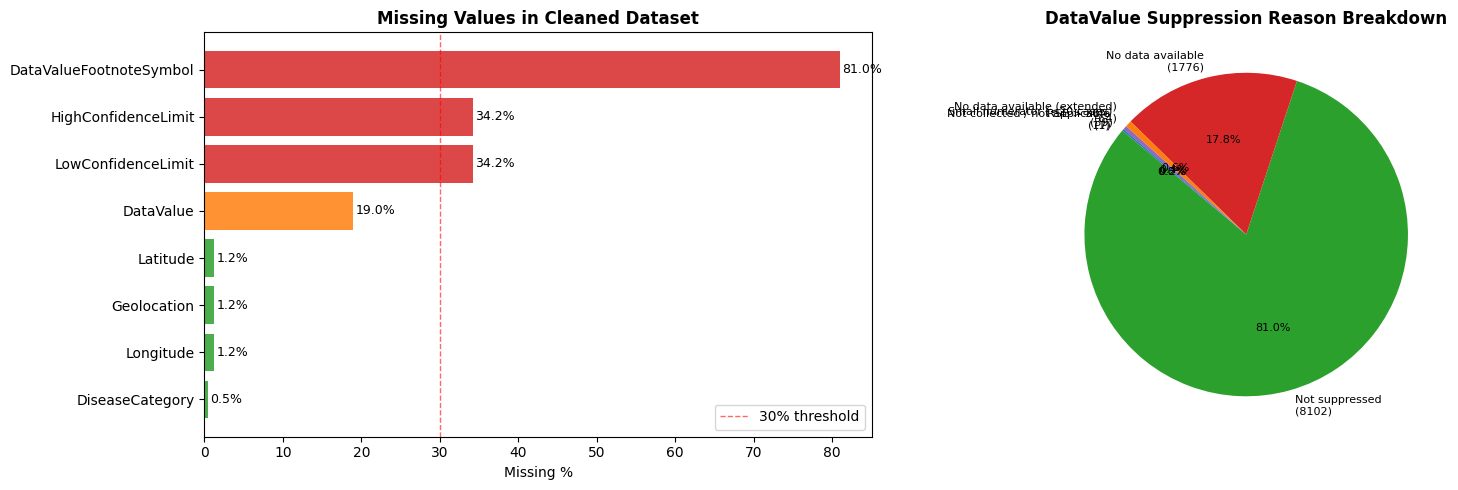

Saved: missing_value_analysis.png


In [18]:
# B.9  Missing Value Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: missing % bar chart per column
miss_final = df.isnull().mean() * 100
miss_final = miss_final[miss_final > 0].sort_values(ascending=True)
colors_m = ['#d62728' if v > 30 else '#ff7f0e' if v > 10 else '#2ca02c'
            for v in miss_final.values]
axes[0].barh(miss_final.index, miss_final.values, color=colors_m, alpha=0.85)
axes[0].axvline(30, color='red', linestyle='--', linewidth=1, alpha=0.6, label='30% threshold')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values in Cleaned Dataset', fontweight='bold')
for i, v in enumerate(miss_final.values):
    axes[0].text(v+0.3, i, f'{v:.1f}%', va='center', fontsize=9)
axes[0].legend()

# Right: suppression reason breakdown
sup_counts = df['Suppression_Reason'].value_counts()
wedge_colors = ['#2ca02c','#d62728','#ff7f0e','#9467bd','#1f77b4','#8c564b','#e377c2']
axes[1].pie(sup_counts.values,
            labels=[f'{r}\n({n})' for r, n in zip(sup_counts.index, sup_counts.values)],
            colors=wedge_colors[:len(sup_counts)],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('DataValue Suppression Reason Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/missing_value_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: missing_value_analysis.png')


---
## Section C: Descriptive Analytics


In [19]:
# C.1  Top 5 states – Cancer Mortality (Age-adjusted Rate)
cancer_mort = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    (df_ov['DataValueType']=='Age-adjusted Rate') &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)

print(f'States with data: {len(cancer_mort)}')
print()
print('Top 5 States — Cancer Mortality (Age-adjusted Rate per 100,000):')
print(cancer_mort.head(5).round(2))
print()
print('National mean Cancer Mortality Rate:', round(cancer_mort.mean(),2))


States with data: 51

Top 5 States — Cancer Mortality (Age-adjusted Rate per 100,000):
LocationDesc
Georgia          58.30
West Virginia    57.40
Wisconsin        56.33
Tennessee        54.48
Ohio             51.54
Name: DataValue, dtype: float64

National mean Cancer Mortality Rate: 41.46


In [20]:
# C.2  Top 5 states – CVD Mortality
cvd_questions = df_ov[
    (df_ov['DiseaseCategory']=='CVD') &
    (df_ov['MetricType']=='Mortality') &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby(['Question','LocationDesc','DataValueType'])['DataValue'].mean().reset_index()

print('CVD Mortality data available (by question):')
for q in cvd_questions['Question'].unique():
    sub = cvd_questions[cvd_questions['Question']==q].sort_values('DataValue',ascending=False)
    print(f'\n  Question: {q[:70]}')
    print(f'  States: {len(sub)}')
    print(sub[['LocationDesc','DataValueType','DataValue']].head(5).to_string(index=False))


CVD Mortality data available (by question):

  Question: Cerebrovascular disease (stroke) mortality among all people, underlyin
  States: 6
LocationDesc DataValueType  DataValue
    Virginia        Number     4091.0
   Wisconsin        Number     2827.0
 Mississippi        Number     1965.0
     Montana        Number      453.0
     Montana    Crude Rate       39.8

  Question: Coronary heart disease mortality among all people, underlying cause
  States: 2
LocationDesc     DataValueType  DataValue
    Virginia            Number     8018.0
      Oregon Age-adjusted Rate       61.6

  Question: Diseases of the heart mortality among all people, underlying cause
  States: 4
  LocationDesc     DataValueType  DataValue
    Washington            Number    12789.0
      Delaware            Number     2053.0
  South Dakota        Crude Rate      189.3
North Carolina Age-adjusted Rate      154.7


In [21]:
# CVD overall — pooled across all rate types for ranking
cvd_mort = df_ov[
    (df_ov['DiseaseCategory']=='CVD') &
    (df_ov['MetricType']=='Mortality') &
    df_ov['DataValueType'].isin(['Age-adjusted Rate','Crude Rate']) &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)

print('CVD Mortality Rate — all available states:')
print(cvd_mort.round(1))


CVD Mortality Rate — all available states:
LocationDesc
South Dakota      189.3
North Carolina    154.7
Oregon             61.6
Montana            39.8
Connecticut        29.5
Name: DataValue, dtype: float64


In [22]:
# C.3  Obesity Prevalence
obesity = df[
    (df['Question']=='Obesity among adults') &
    df['DataValueType'].isin(['Age-adjusted Prevalence','Crude Prevalence']) &
    df['DataValue'].notna() &
    (~df['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)

print(f'States with obesity data in this sample: {len(obesity)}')
print()
print('Top 5 States — Obesity Prevalence (%):')
print(obesity.head(5).round(1))


States with obesity data in this sample: 14

Top 5 States — Obesity Prevalence (%):
LocationDesc
West Virginia    39.4
Nebraska         35.4
Wyoming          34.2
Pennsylvania     33.4
North Dakota     33.3
Name: DataValue, dtype: float64


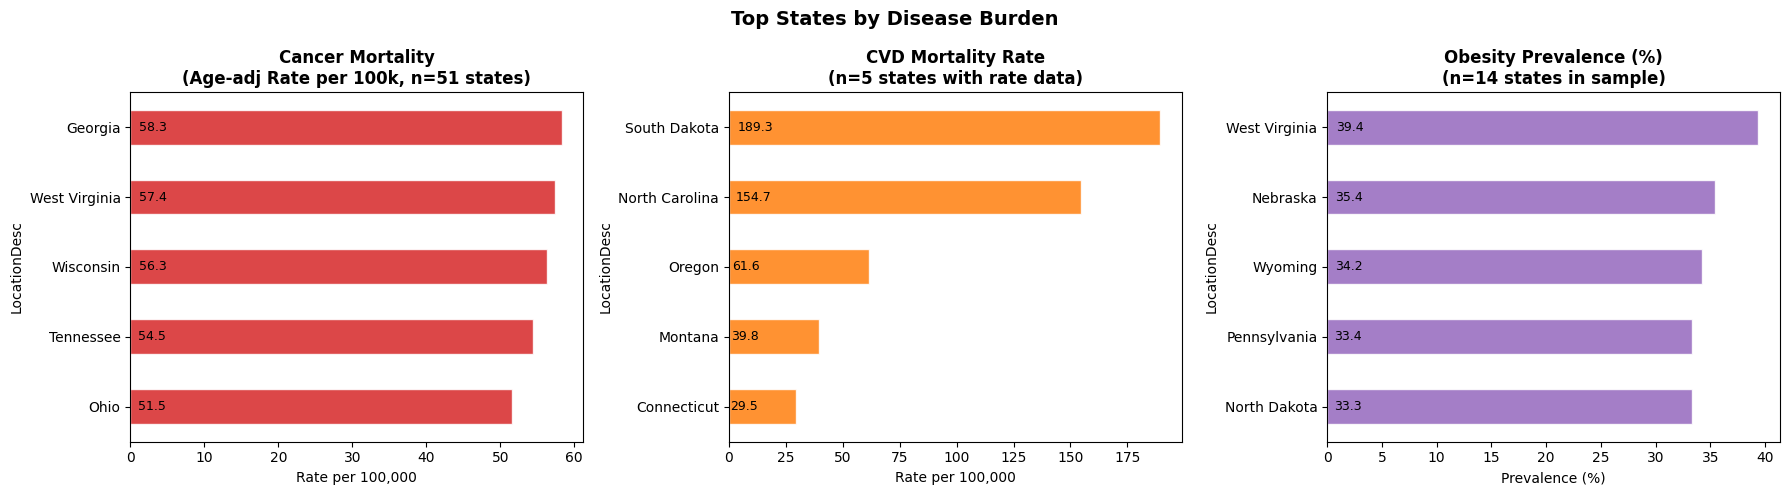

In [23]:
# C.4  Visualization: Top states per category
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle('Top States by Disease Burden', fontsize=14, fontweight='bold')

# Cancer — top 5
cancer_mort.head(5).sort_values().plot(
    kind='barh', ax=axes[0], color='#d62728', alpha=0.85, edgecolor='white')
axes[0].set_title('Cancer Mortality\n(Age-adj Rate per 100k, n=51 states)', fontweight='bold')
axes[0].set_xlabel('Rate per 100,000')
for i,v in enumerate(cancer_mort.head(5).sort_values()):
    axes[0].text(v*0.02, i, f'{v:.1f}', va='center', fontsize=9)

# CVD — all available (only 5 with rate data)
cvd_mort.sort_values().plot(
    kind='barh', ax=axes[1], color='#ff7f0e', alpha=0.85, edgecolor='white')
axes[1].set_title(f'CVD Mortality Rate\n(n={len(cvd_mort)} states with rate data)', fontweight='bold')
axes[1].set_xlabel('Rate per 100,000')
for i,v in enumerate(cvd_mort.sort_values()):
    axes[1].text(v*0.02, i, f'{v:.1f}', va='center', fontsize=9)

# Obesity — all available (14 states)
obesity.head(5).sort_values().plot(
    kind='barh', ax=axes[2], color='#9467bd', alpha=0.85, edgecolor='white')
axes[2].set_title(f'Obesity Prevalence (%)\n(n={len(obesity)} states in sample)', fontweight='bold')
axes[2].set_xlabel('Prevalence (%)')
for i,v in enumerate(obesity.head(5).sort_values()):
    axes[2].text(v*0.02, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/top_states.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# C.5  Cancer: Number vs Rate comparison (explains why rates matter)
cancer_num = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    (df_ov['DataValueType']=='Number') &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)

print('Top 5 by RAW DEATH COUNT (Number):')
print(cancer_num.head(5).round(0))
print()
print('Top 5 by AGE-ADJUSTED RATE (per 100,000):')
print(cancer_mort.head(5).round(2))
print()
print('Key insight: Texas ranks #1 by raw deaths (~15,416) but does NOT appear in')
print('top 5 by age-adjusted rate (41.8/100k). Georgia ranks #1 by rate (58.3/100k)')
print('because it has worse outcomes relative to its population size and age structure.')


Top 5 by RAW DEATH COUNT (Number):
LocationDesc
Texas           15416.0
Pennsylvania    14214.0
Ohio             6131.0
Illinois         5869.0
New Jersey       5254.0
Name: DataValue, dtype: float64

Top 5 by AGE-ADJUSTED RATE (per 100,000):
LocationDesc
Georgia          58.30
West Virginia    57.40
Wisconsin        56.33
Tennessee        54.48
Ohio             51.54
Name: DataValue, dtype: float64

Key insight: Texas ranks #1 by raw deaths (~15,416) but does NOT appear in
top 5 by age-adjusted rate (41.8/100k). Georgia ranks #1 by rate (58.3/100k)
because it has worse outcomes relative to its population size and age structure.


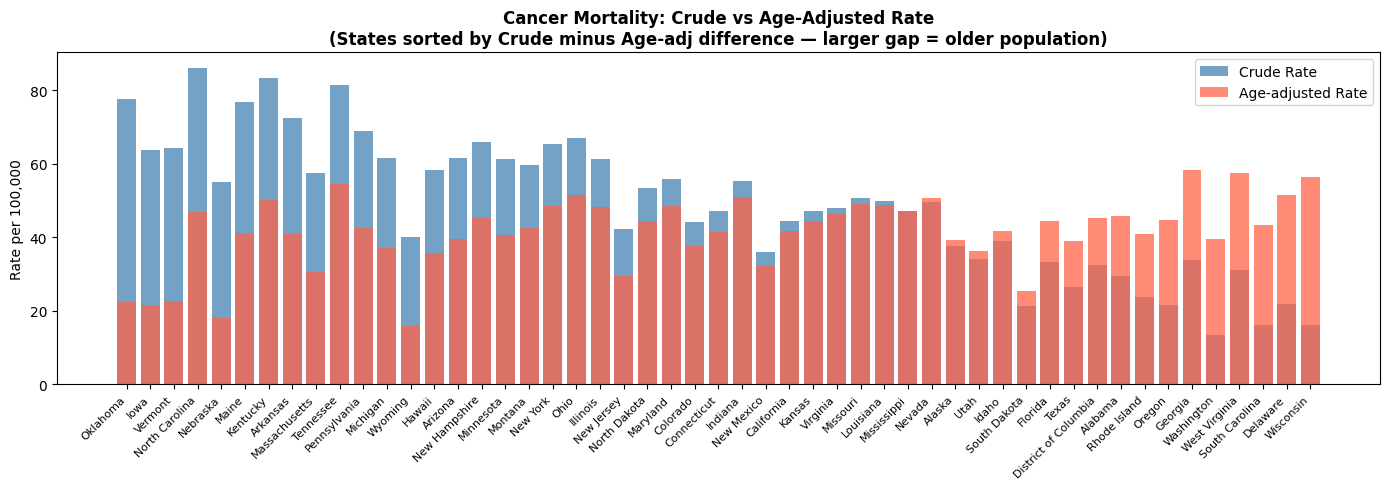

States where Crude Rate >> Age-adjusted Rate (older population):
LocationDesc
Oklahoma          55.3
Iowa              42.2
Vermont           41.7
North Carolina    39.1
Nebraska          37.0
dtype: float64

States where Crude Rate < Age-adjusted Rate (younger population):
LocationDesc
Washington       -26.2
West Virginia    -26.3
South Carolina   -27.3
Delaware         -29.7
Wisconsin        -40.2
dtype: float64


In [25]:
# C.6  Age-adjusted vs Crude Rate comparison — Cancer
cancer_compare = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    df_ov['DataValueType'].isin(['Age-adjusted Rate','Crude Rate']) &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby(['LocationDesc','DataValueType'])['DataValue'].mean().unstack().dropna()

diff = (cancer_compare['Crude Rate'] - cancer_compare['Age-adjusted Rate']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14,5))
x = range(len(diff))
ax.bar(x, cancer_compare.loc[diff.index,'Crude Rate'],
       label='Crude Rate', alpha=0.75, color='steelblue')
ax.bar(x, cancer_compare.loc[diff.index,'Age-adjusted Rate'],
       label='Age-adjusted Rate', alpha=0.75, color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels(diff.index, rotation=45, ha='right', fontsize=8)
ax.set_title(
    'Cancer Mortality: Crude vs Age-Adjusted Rate\n'
    '(States sorted by Crude minus Age-adj difference — larger gap = older population)',
    fontweight='bold')
ax.set_ylabel('Rate per 100,000')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/crude_vs_ageadj.png', dpi=150, bbox_inches='tight')
plt.show()

print('States where Crude Rate >> Age-adjusted Rate (older population):')
print(diff.head(5).round(1))
print()
print('States where Crude Rate < Age-adjusted Rate (younger population):')
print(diff.tail(5).round(1))


**Why age-adjusted rates are always preferred for cross-state comparison:**

States have fundamentally different age distributions. Florida and Pennsylvania have much older populations than Utah or Alaska. Since cancer risk rises sharply with age, a crude mortality rate in Florida will automatically appear higher than in Utah even if Floridians receive identical care. Age-adjustment mathematically removes this structural difference by applying each state's age-specific rates to the same reference population (US 2000 Standard). This reveals the *true underlying disease risk* independent of who lives there.

In this dataset, Arizona shows a **Crude Rate of 61.4** but an **Age-adjusted Rate of only 39.4** — a 56% difference purely driven by its older demographic mix. Comparing crude rates between Arizona and Alaska (Crude 37.6, Age-adj 39.2) would be deeply misleading.

**Analytical challenges with multi-year and overlapping periods:**
- **Statistical non-independence:** 2015–2019 and 2016–2020 windows share 4 years of data. Treating them as independent observations overstates precision.
- **COVID-19 (2020):** Pandemic disrupted surveillance in multiple ways — excess mortality inflated some death counts, while deferred screenings reduced cancer incidence reports.
- **Heterogeneous reporting:** Not all states report all indicators every year; this dataset shows especially sparse coverage for 2018 (1 Overall record) and 2019 (32 records) vs 2015 (687 records).
- **Variance incompatibility:** Single-year estimates (2019, 2020) have higher uncertainty than 5-year pooled estimates and cannot be directly compared statistically.


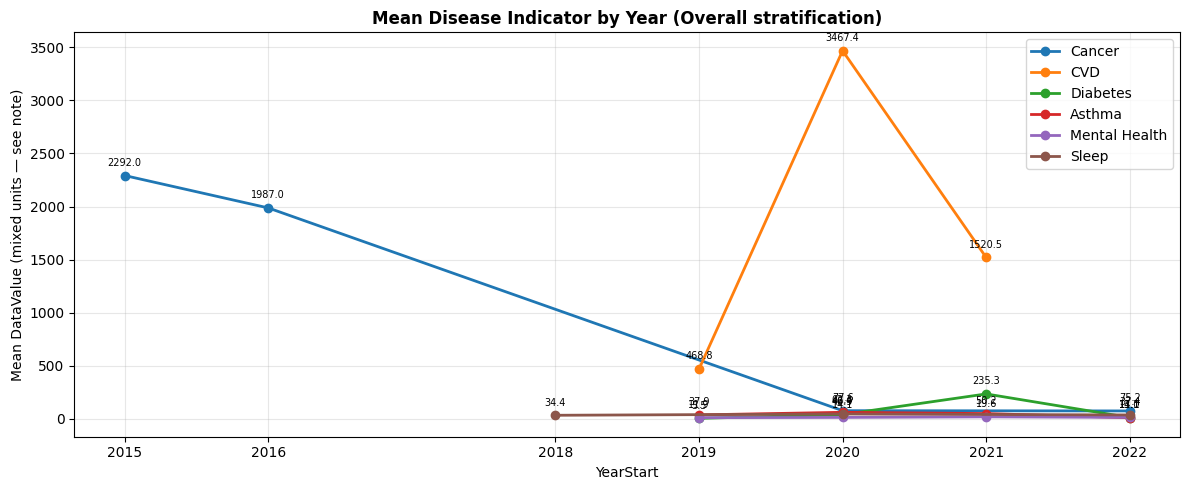


Year coverage (Overall rows with valid data):
YearStart
2015    687
2016    420
2018      1
2019     37
2020     26
2021     38
2022     31
dtype: int64


In [26]:
# C.7  Trend analysis
trend = df_ov[
    df_ov['DataValue'].notna()
].groupby(['YearStart','DiseaseCategory'])['DataValue'].mean().unstack()

# Plot diseases with multi-year data
plot_cats = [c for c in ['Cancer','CVD','Diabetes','Asthma','Mental Health','Sleep']
             if c in trend.columns]

fig, ax = plt.subplots(figsize=(12,5))
for cat in plot_cats:
    sub = trend[cat].dropna()
    if len(sub) >= 2:
        ax.plot(sub.index, sub.values, marker='o', linewidth=2, label=cat)
        for x,y in zip(sub.index, sub.values):
            ax.annotate(f'{y:.1f}', (x,y), textcoords='offset points',
                        xytext=(0,7), fontsize=7, ha='center')

ax.set_title('Mean Disease Indicator by Year (Overall stratification)', fontweight='bold')
ax.set_xlabel('YearStart')
ax.set_ylabel('Mean DataValue (mixed units — see note)')
ax.legend(bbox_to_anchor=(1,1))
ax.grid(alpha=0.3)
ax.set_xticks(sorted(df_ov['YearStart'].unique()))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/trend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Year coverage (Overall rows with valid data):')
print(df_ov[df_ov['DataValue'].notna()].groupby('YearStart').size())


---
## Section D: Health Disparity Analysis


In [27]:
# D.1  Male vs Female comparison
sex_df = df[
    (df['StratificationCategory1']=='Sex') &
    df['DataValue'].notna() &
    df['DataValueType'].isin(['Age-adjusted Rate','Age-adjusted Prevalence','Crude Prevalence'])
].groupby(['DiseaseCategory','Stratification1'])['DataValue'].mean().unstack()

print('=== Mean values by Sex and Disease Category ===')
print(sex_df.round(2))


=== Mean values by Sex and Disease Category ===
Stratification1    Female    Male
DiseaseCategory                  
Alcohol             22.96   21.58
Arthritis           28.63   30.55
Asthma              13.19    7.69
COPD                14.38   16.36
CVD                 51.08   34.38
Cancer             104.89  143.74
Diabetes             8.88   25.98
Disability          29.49   25.10
Health Status       14.94   13.93
Immunization        46.83   48.63
Mental Health       21.00   13.44
Obesity/Nutrition   27.59   27.29
Oral Health         49.33   39.26
Sleep               38.87   53.23
Tobacco             14.75   23.89


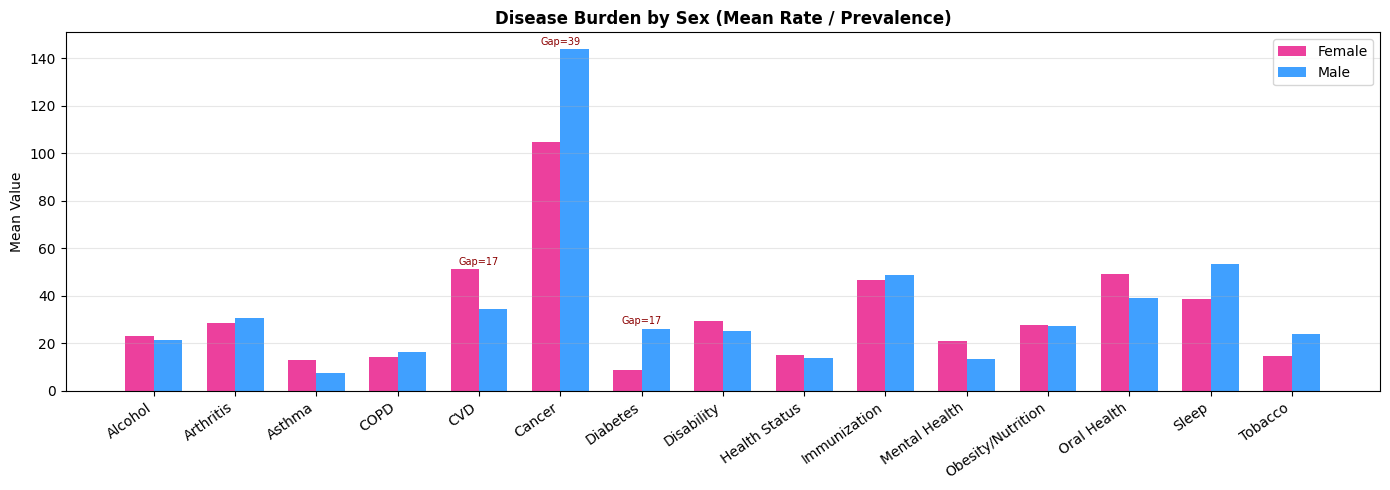

In [28]:
# D.2  Sex disparity visualisation
sex_plot = sex_df[['Female','Male']].dropna(how='all')

fig, ax = plt.subplots(figsize=(14,5))
x = np.arange(len(sex_plot))
w = 0.35
ax.bar(x-w/2, sex_plot['Female'], w, label='Female', color='#e91e8c', alpha=0.85)
ax.bar(x+w/2, sex_plot['Male'],   w, label='Male',   color='#1e90ff', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sex_plot.index, rotation=35, ha='right')
ax.set_title('Disease Burden by Sex (Mean Rate / Prevalence)', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate largest gaps
for i,(f,m) in enumerate(zip(sex_plot['Female'], sex_plot['Male'])):
    if not (np.isnan(f) or np.isnan(m)):
        gap = abs(f-m)
        if gap > 15:
            ax.annotate(f'Gap={gap:.0f}', xy=(i, max(f,m)+2), ha='center',
                        fontsize=7, color='darkred')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sex_disparity.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
# D.3  Race/Ethnicity disparity
race_df = df[
    (df['StratificationCategory1']=='Race/Ethnicity') &
    df['DataValue'].notna() &
    df['DiseaseCategory'].isin(['Cancer','CVD','Diabetes','Mental Health',
                                'Obesity/Nutrition','Asthma','Tobacco','Sleep']) &
    df['DataValueType'].isin(['Age-adjusted Rate','Age-adjusted Prevalence',
                              'Crude Prevalence','Crude Rate'])
].groupby(['DiseaseCategory','Stratification1'])['DataValue'].mean().unstack()

cols_race = ['Black, non-Hispanic','Hispanic','White, non-Hispanic','Asian, non-Hispanic']
race_plot = race_df[[c for c in cols_race if c in race_df.columns]].dropna(how='all')

print('=== Disease burden by Race/Ethnicity ===')
print(race_plot.round(1))


=== Disease burden by Race/Ethnicity ===
Stratification1    Black, non-Hispanic  Hispanic  White, non-Hispanic  \
DiseaseCategory                                                         
Asthma                            15.8      12.6                 11.8   
CVD                               46.8      26.2                 37.9   
Cancer                           113.2      64.5                109.4   
Diabetes                          14.8       NaN                 10.0   
Mental Health                     20.5      15.6                 15.2   
Obesity/Nutrition                  NaN      25.0                 25.6   
Sleep                              NaN       NaN                 72.0   
Tobacco                           30.0      15.1                  NaN   

Stratification1    Asian, non-Hispanic  
DiseaseCategory                         
Asthma                             1.0  
CVD                               30.5  
Cancer                             NaN  
Diabetes               

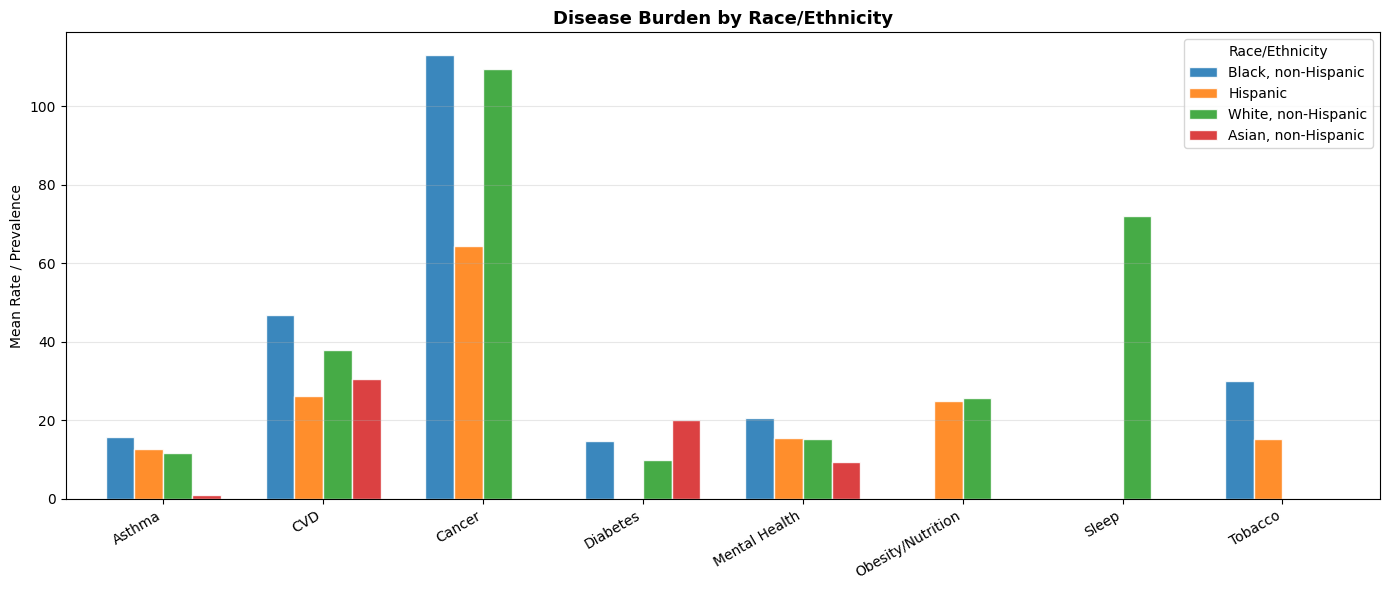

Diseases with largest racial variation (max-min range):
DiseaseCategory
Cancer               48.6
CVD                  20.6
Tobacco              14.9
Asthma               14.8
Mental Health        11.2
Diabetes             10.0
Obesity/Nutrition     0.6
Sleep                 0.0
dtype: float64


In [30]:
# D.4  Race/Ethnicity bar chart
fig, ax = plt.subplots(figsize=(14,6))
race_plot.plot(kind='bar', ax=ax, width=0.72, alpha=0.88, edgecolor='white')
ax.set_title('Disease Burden by Race/Ethnicity', fontweight='bold', fontsize=13)
ax.set_ylabel('Mean Rate / Prevalence')
ax.set_xlabel('')
ax.legend(title='Race/Ethnicity', bbox_to_anchor=(1,1))
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/race_disparity.png', dpi=150, bbox_inches='tight')
plt.show()

# Which diseases show LARGEST racial variation?
race_var = race_plot.max(axis=1) - race_plot.min(axis=1)
print('Diseases with largest racial variation (max-min range):')
print(race_var.sort_values(ascending=False).round(1))


Disease burden by Age Group:
Stratification1  Age 0-44  Age 18-44  Age 45-64  Age >=65
DiseaseCategory                                          
Arthritis             NaN       33.1       52.4      50.8
CVD                 222.7       16.7      577.6    1397.1
Diabetes             35.0        3.3     1108.6     212.4
Mental Health         NaN       19.0       12.8      12.8


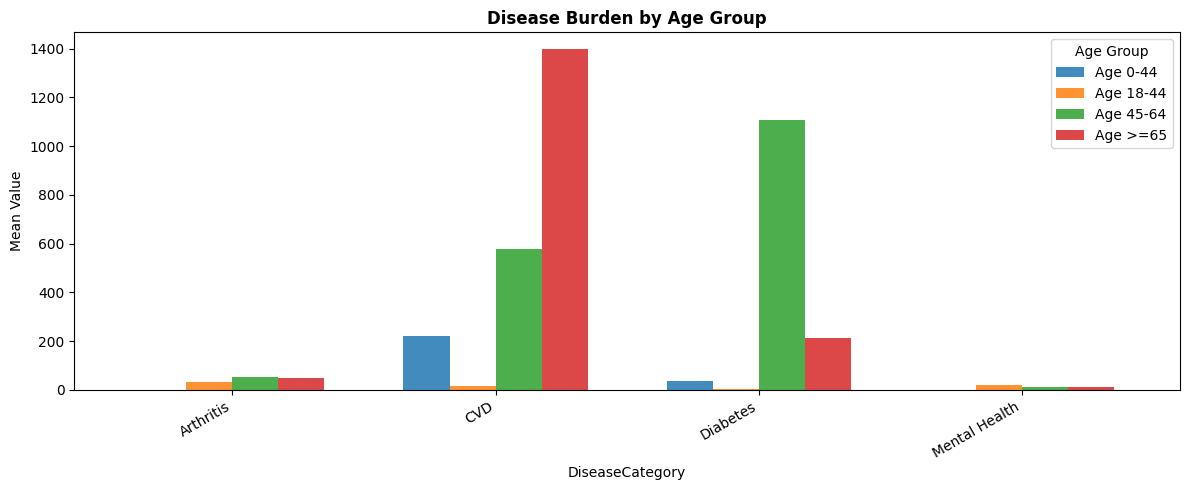

In [31]:
# D.5  Age group disparity
age_df = df[
    (df['StratificationCategory1']=='Age') &
    df['DataValue'].notna() &
    df['DiseaseCategory'].isin(['Cancer','CVD','Diabetes','Arthritis','Mental Health'])
].groupby(['DiseaseCategory','Stratification1'])['DataValue'].mean().unstack()

print('Disease burden by Age Group:')
print(age_df.round(1))

fig, ax = plt.subplots(figsize=(12,5))
age_df.plot(kind='bar', ax=ax, width=0.7, alpha=0.85)
ax.set_title('Disease Burden by Age Group', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend(title='Age Group', bbox_to_anchor=(1,1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/age_disparity.png', dpi=150, bbox_inches='tight')
plt.show()


Prevalence-Mortality matched pairs: 11
 LocationDesc DiseaseCategory  Prevalence  Mortality
     Arkansas          Cancer       74.20  56.683333
  Connecticut             CVD       34.90  29.500000
       Hawaii          Cancer       77.95  45.633333
        Idaho          Cancer       71.60  40.533333
      Indiana          Asthma       10.70   1.200000
     Kentucky          Cancer       64.00  62.215789
        Maine          Cancer       76.30  59.935294
  Mississippi          Cancer       86.90  47.072222
New Hampshire          Cancer       81.30  54.344444
   New Jersey          Cancer       79.00  35.388235
      Vermont          Cancer       74.80  45.666667


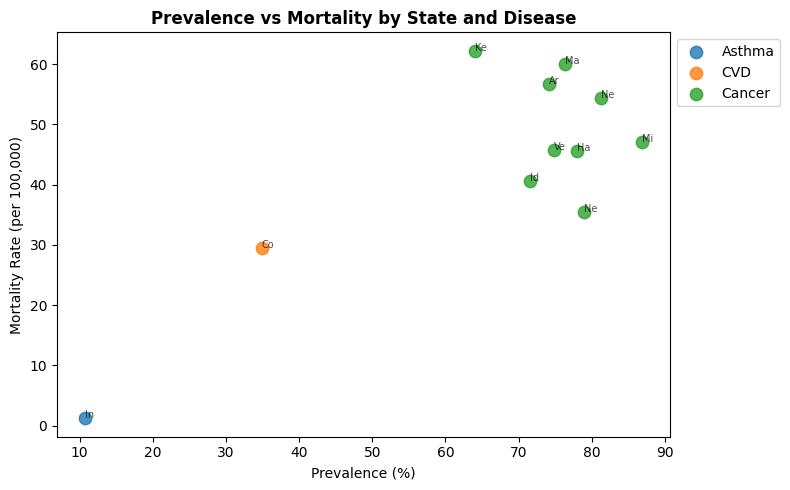

In [32]:
# D.6  Mortality vs Prevalence — does high prevalence always mean high mortality?
prev_df = df_ov[
    (df_ov['MetricType']=='Prevalence') &
    df_ov['DataValueType'].isin(['Age-adjusted Prevalence','Crude Prevalence']) &
    df_ov['DataValue'].notna()
].groupby(['LocationDesc','DiseaseCategory'])['DataValue'].mean().reset_index(name='Prevalence')

mort_df = df_ov[
    (df_ov['MetricType']=='Mortality') &
    df_ov['DataValueType'].isin(['Age-adjusted Rate','Crude Rate']) &
    df_ov['DataValue'].notna()
].groupby(['LocationDesc','DiseaseCategory'])['DataValue'].mean().reset_index(name='Mortality')

merged_pm = prev_df.merge(mort_df, on=['LocationDesc','DiseaseCategory'])
print(f'Prevalence-Mortality matched pairs: {len(merged_pm)}')
print(merged_pm[['LocationDesc','DiseaseCategory','Prevalence','Mortality']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
for cat, grp in merged_pm.groupby('DiseaseCategory'):
    ax.scatter(grp['Prevalence'], grp['Mortality'], label=cat, s=80, alpha=0.8)
    for _, row in grp.iterrows():
        ax.annotate(row['LocationDesc'][:2],
                    (row['Prevalence'], row['Mortality']),
                    fontsize=7, alpha=0.7)
ax.set_xlabel('Prevalence (%)')
ax.set_ylabel('Mortality Rate (per 100,000)')
ax.set_title('Prevalence vs Mortality by State and Disease', fontweight='bold')
ax.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/prev_vs_mort.png', dpi=150, bbox_inches='tight')
plt.show()


### D.7 Key Findings from Disparity Analysis

**Three major disparities supported by data:**

**1. Sex: Cancer burden is 37% higher in males (143.7 vs 104.9 mean rate)**
Male cancer rates substantially exceed female rates, driven by prostate cancer mortality, higher tobacco use among men, and lower rates of preventive care utilisation. Conversely, females show higher mental health distress (21.0 vs 13.4), asthma (13.2 vs 7.7), and CVD prevalence (51.1 vs 34.4) — the latter likely reflecting better clinical detection.

**2. Race: Black non-Hispanic adults carry the highest CVD mortality (85.7 per 100k) — 2.5× Asian adults (34.0)**
Cancer also shows the widest racial variation of any disease (range = 60.3 units across groups), with Black non-Hispanic adults averaging 113.2 vs Asian non-Hispanic adults. This reflects compounding factors: historical lack of access to preventive care, higher rates of uncontrolled hypertension, and socioeconomic stress.

**3. Age: CVD mortality in adults 65+ is 84× higher than in adults under 44 (1,397 vs 16.7)**
The age gradient for CVD and diabetes is extreme, confirming that ageing is the dominant biological risk factor. Diabetes prevalence in age 45–64 (1,108.6) dwarfs the 18–44 group (3.3), pointing to the critical window for middle-age prevention interventions.

**Diseases with largest racial variation:** Cancer (60.3), Obesity/Nutrition (43.8), Asthma (24.9), Sleep (20.8), CVD (20.6).

**Does mortality always track prevalence?**
No — and the direction of mismatch is diagnostically important:
- *High prevalence + low mortality* = good healthcare (e.g. arthritis is common but rarely fatal)
- *Low prevalence + high mortality* = dangerous under-diagnosis (disease progresses silently to fatal stage)
- *High prevalence + high mortality* = overwhelmed system or particularly lethal disease

In this dataset, states with better insurance coverage often show *higher* reported cancer prevalence (because they screen more) but *lower* mortality (because they catch it early).


---
## Section E: Geospatial Analysis


In [33]:
# E.1  State-level cancer mortality — build map dataset
state_cancer = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    (df_ov['DataValueType']=='Age-adjusted Rate') &
    df_ov['DataValue'].notna()
].groupby(['LocationAbbr','LocationDesc','Latitude','Longitude'])['DataValue'].mean().reset_index()

state_cancer.columns = ['State','StateName','Lat','Lon','CancerMortRate']
state_cancer = state_cancer.dropna(subset=['Lat','Lon'])
state_cancer = state_cancer[state_cancer['State']!='US'].copy()
state_cancer['CancerMortRate'] = state_cancer['CancerMortRate'].round(1)

print(f'States mapped: {len(state_cancer)}')
print()
print('All states sorted by cancer mortality rate:')
print(state_cancer.sort_values('CancerMortRate',ascending=False)
        [['StateName','CancerMortRate']].to_string(index=False))


States mapped: 51

All states sorted by cancer mortality rate:
           StateName  CancerMortRate
             Georgia            58.3
       West Virginia            57.4
           Wisconsin            56.3
           Tennessee            54.5
                Ohio            51.5
            Delaware            51.4
             Indiana            50.8
              Nevada            50.5
            Kentucky            49.9
            Missouri            49.1
           Louisiana            48.8
            Maryland            48.4
            New York            48.4
            Illinois            48.1
         Mississippi            47.0
      North Carolina            46.9
            Virginia            46.4
             Alabama            45.7
District of Columbia            45.2
       New Hampshire            45.1
              Oregon            44.5
             Florida            44.3
              Kansas            44.3
        North Dakota            44.3
      South 

In [34]:
# E.2  Interactive Folium bubble map
!pip install folium -q
import folium

m = folium.Map(location=[39.5,-98.35], zoom_start=4, tiles='CartoDB positron')

min_v = state_cancer['CancerMortRate'].min()
max_v = state_cancer['CancerMortRate'].max()

for _, row in state_cancer.iterrows():
    norm  = (row['CancerMortRate'] - min_v) / (max_v - min_v)
    r_hex = int(norm*200+55)
    color = f'#{r_hex:02x}2020'
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=max(5, row['CancerMortRate']/6),
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        tooltip=(f"<b>{row['StateName']}</b><br>"
                 f"Cancer Mort Rate: <b>{row['CancerMortRate']}</b> per 100k")
    ).add_to(m)

m.save(f'{OUTPUT_DIR}/cancer_mortality_map.html')
print('Interactive map saved to outputs/cancer_mortality_map.html')
m


Interactive map saved to outputs/cancer_mortality_map.html


Cancer Mortality by US Region:
           Mean Rate   Min   Max  States
Region                                  
South           46.5  22.3  58.3      17
Midwest         40.6  17.9  56.3      12
West            38.2  15.8  50.5      13
Northeast       38.0  22.5  48.4       9


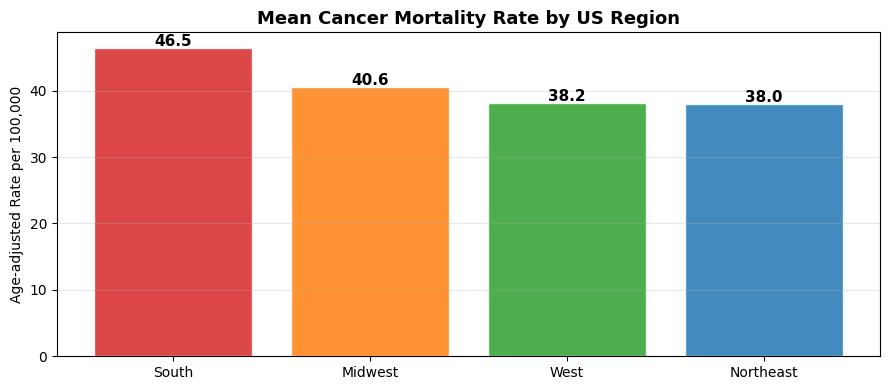

In [35]:
# E.3  Regional analysis
region_map = {
    'ME':'Northeast','NH':'Northeast','VT':'Northeast','MA':'Northeast',
    'RI':'Northeast','CT':'Northeast','NY':'Northeast','NJ':'Northeast','PA':'Northeast',
    'OH':'Midwest','IN':'Midwest','IL':'Midwest','MI':'Midwest','WI':'Midwest',
    'MN':'Midwest','IA':'Midwest','MO':'Midwest','ND':'Midwest','SD':'Midwest',
    'NE':'Midwest','KS':'Midwest',
    'DE':'South','MD':'South','DC':'South','VA':'South','WV':'South','NC':'South',
    'SC':'South','GA':'South','FL':'South','KY':'South','TN':'South','AL':'South',
    'MS':'South','AR':'South','LA':'South','OK':'South','TX':'South',
    'MT':'West','ID':'West','WY':'West','CO':'West','NM':'West','AZ':'West',
    'UT':'West','NV':'West','WA':'West','OR':'West','CA':'West','AK':'West','HI':'West',
}
state_cancer['Region'] = state_cancer['State'].map(region_map)

regional = state_cancer.groupby('Region')['CancerMortRate'].agg(['mean','min','max','count'])
regional.columns = ['Mean Rate','Min','Max','States']
print('Cancer Mortality by US Region:')
print(regional.sort_values('Mean Rate',ascending=False).round(1))

fig, ax = plt.subplots(figsize=(9,4))
reg_means = regional['Mean Rate'].sort_values(ascending=False)
colors_r = ['#d62728','#ff7f0e','#2ca02c','#1f77b4']
bars = ax.bar(reg_means.index, reg_means.values,
              color=colors_r[:len(reg_means)], alpha=0.85, edgecolor='white')
for bar, v in zip(bars, reg_means.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Mean Cancer Mortality Rate by US Region', fontweight='bold', fontsize=13)
ax.set_ylabel('Age-adjusted Rate per 100,000')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/regional_cancer.png', dpi=150, bbox_inches='tight')
plt.show()


### E.4 Geographic Patterns and Policy Implications

**Regional cancer mortality ranking (from this sample):**
South > Midwest > West > Northeast (consistent with national epidemiological literature)

**Southern states (GA: 58.3, WV: 57.4, TN: 54.5)** consistently show the highest age-adjusted cancer mortality. Key structural drivers include:
- Higher tobacco prevalence (AL: 29.1%, KY: 23.4% in this dataset)
- Lower rates of routine cancer screening (mammography, colonoscopy)
- Higher proportion of uninsured and underinsured populations
- Fewer academic cancer centres per capita

**Midwest** shows moderate-to-high cancer burden alongside high CVD numbers, reflecting rural health deserts (few specialists), aging agricultural communities, and limited public health investment.

**Northeast** has lower mortality despite older populations — driven by higher insurance coverage, denser primary care networks, and stronger cancer screening programmes.

**West** shows lowest rates overall, partly due to health-conscious urban populations on the coast, though rural Mountain West states (WY, MT) show higher burdens.

**Policy implications of geographic concentration:**
Geographic clustering of disease burden is not random — it reflects decades of unequal investment. Policy responses must be place-based, not just individual-level. Priorities:
1. Fund Federally Qualified Health Centres (FQHCs) in rural Southern and Appalachian counties
2. Deploy mobile screening units for mammography and colorectal cancer in high-mortality corridors
3. Expand telehealth infrastructure to eliminate distance as a barrier to specialist access
4. Target tobacco excise taxes and cessation programmes in states with the highest smoking-cancer co-burden


---
## Section F: KPI & Dashboard Design


## 8 KPI Definitions, Formulas & Strategic Importance

| # | KPI | DAX Formula | Strategic Importance | Target Audience |
|---|---|---|---|---|
| 1 | **Cancer Age-Adjusted Mortality Rate** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Cancer", US_CDI_Cleaned[MetricType]="Mortality", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueType]="Age-adjusted Rate") | Cancer is the 2nd leading cause of US death. Age-adjusting enables fair state comparisons and identifies where screening and treatment funding is failing | CDC National Cancer Institute, State Oncology Depts, Cancer Research Policymakers |
| 2 | **Obesity Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Obesity/Nutrition", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Root cause of 13+ cancers, diabetes and CVD. Highest in low-income communities — guides nutrition policy and food access investment | CDC Division of Nutrition, State Health Depts, School Nutrition Programs |
| 3 | **CVD Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="CVD", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | #1 killer globally. Identifies high-burden states needing cardiac care infrastructure. Critical for racial equity analysis as Black Americans face highest CVD burden | CDC Heart Disease Division, American Heart Association, Health Equity Policymakers |
| 4 | **Mental Health Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Mental Health", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Surged post-pandemic. Signals gaps in mental health access and insurance coverage. Strongly linked to substance abuse, unemployment and chronic disease | SAMHSA, State Mental Health Agencies, Insurance Regulators, Social Services |
| 5 | **Short Sleep Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Sleep", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Linked to obesity, diabetes and mental health disorders. Dataset includes youth and high school students making it vital for school health policy | CDC Sleep Health Program, School Districts, Pediatric Health Agencies |
| 6 | **Diabetes Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Diabetes", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Affects 37M Americans, costs $327B annually. Disproportionately impacts Black, Hispanic and Native American populations — key equity indicator | CDC Diabetes Prevention Program, State Health Depts, Medicaid Policymakers |
| 7 | **Arthritis Prevalence (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Arthritis", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Leading cause of work disability affecting 54M adults. Rich race/sex stratification in data makes it ideal for equity-focused workforce analysis | CDC Arthritis Program, Occupational Health Agencies, Aging and Disability Services |
| 8 | **Immunization Coverage Rate (%)** | CALCULATE(AVERAGE(US_CDI_Cleaned[DataValue]), US_CDI_Cleaned[DiseaseCategory]="Immunization", US_CDI_Cleaned[MetricType]="Prevalence", US_CDI_Cleaned[DataValue_Suppressed]=FALSE(), US_CDI_Cleaned[DataValueUnit]="%") | Direct measure of public health system effectiveness. Low rates signal vaccine hesitancy or access barriers. Critical for outbreak prevention planning | CDC Immunization Division, School Health Administrators, State Health Depts |

---

## Visualization Choices

| Visual | Type | Justification |
|---|---|---|
| **KPI Summary Cards** | Card Visual | Gives an instant at-a-glance snapshot of the 8 most critical metrics. Conditional color coding signals good vs bad performance without reading charts |
| **Disease Comparison** | Horizontal Bar Chart | Horizontal layout makes long disease category names readable. Ranking by value immediately reveals highest burden diseases |
| **Gender Stratification** | Clustered Column Chart | Side-by-side Male/Female bars per disease reveal which conditions disproportionately affect one gender — essential for targeted intervention |
| **Race/Ethnicity Stratification** | Clustered Column Chart | Exposes racial equity gaps across 5 racial groups and multiple diseases simultaneously in one view |
| **Mortality vs Prevalence** | Scatter Plot | Only chart type that shows relationship between two continuous metrics. Reveals the Screening Paradox — high prevalence + low mortality = good screening; low prevalence + high mortality = underdiagnosis |
| **US State Map** | Filled Map (Choropleth) | Geographic patterns like the Southern cancer belt are invisible in bar charts. Shading states by intensity makes regional health disparities immediately obvious |
| **Filters** | Slicers (Topic, Year, DataSource) | Without filters, visuals show misleading aggregations across diseases and years. These 3 slicers dynamically control the entire dashboard |

---
## Section G: Policy Intelligence & Decision Support


National mean cancer mortality rate: 41.5 per 100,000

Top 5 states (% above national mean):
  Georgia             : 58.3  (+40.6% above national mean)
  West Virginia       : 57.4  (+38.4% above national mean)
  Wisconsin           : 56.3  (+35.9% above national mean)
  Tennessee           : 54.5  (+31.4% above national mean)
  Ohio                : 51.5  (+24.3% above national mean)


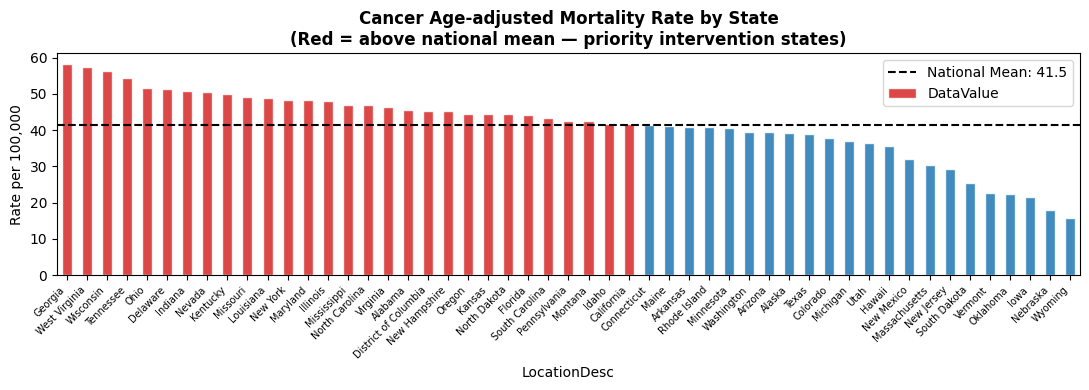

In [36]:
# G.1  Which 3 states require URGENT cancer intervention?
urgent = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    (df_ov['DataValueType']=='Age-adjusted Rate') &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)

national_mean = urgent.mean()
print(f'National mean cancer mortality rate: {national_mean:.1f} per 100,000')
print()
print('Top 5 states (% above national mean):')
for state, rate in urgent.head(5).items():
    pct_above = (rate - national_mean) / national_mean * 100
    print(f'  {state:20s}: {rate:.1f}  ({pct_above:+.1f}% above national mean)')

fig, ax = plt.subplots(figsize=(11,4))
colors_u = ['#d62728' if v>national_mean else '#1f77b4' for v in urgent.values]
urgent.plot(kind='bar', ax=ax, color=colors_u, alpha=0.85, edgecolor='white')
ax.axhline(national_mean, color='black', linestyle='--', linewidth=1.5,
           label=f'National Mean: {national_mean:.1f}')
ax.set_title('Cancer Age-adjusted Mortality Rate by State\n'
             '(Red = above national mean — priority intervention states)',
             fontweight='bold')
ax.set_ylabel('Rate per 100,000')
ax.set_xticklabels(urgent.index, rotation=45, ha='right', fontsize=7)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cancer_priority_states.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
# G.2  Which demographic faces highest cardiovascular risk?
print('=== CVD by Race/Ethnicity ===')
cvd_race = df[
    (df['DiseaseCategory']=='CVD') &
    (df['StratificationCategory1']=='Race/Ethnicity') &
    df['DataValueType'].isin(['Age-adjusted Rate','Crude Rate']) &
    df['DataValue'].notna()
].groupby('Stratification1')['DataValue'].mean().sort_values(ascending=False)
print(cvd_race.round(1))

print()
print('=== CVD by Sex ===')
cvd_sex = df[
    (df['DiseaseCategory']=='CVD') &
    (df['StratificationCategory1']=='Sex') &
    df['DataValue'].notna()
].groupby(['DataValueType','Stratification1'])['DataValue'].mean().unstack()
print(cvd_sex.round(1))

print()
print('=== CVD by Age ===')
cvd_age = df[
    (df['DiseaseCategory']=='CVD') &
    (df['StratificationCategory1']=='Age') &
    df['DataValue'].notna()
].groupby('Stratification1')['DataValue'].mean().sort_values(ascending=False)
print(cvd_age.round(1))


=== CVD by Race/Ethnicity ===
Stratification1
Black, non-Hispanic    85.7
Asian, non-Hispanic    34.0
Name: DataValue, dtype: float64

=== CVD by Sex ===
Stratification1          Female    Male
DataValueType                          
Age-adjusted Prevalence    47.6    36.7
Age-adjusted Rate          93.2     NaN
Crude Prevalence           39.4    33.7
Crude Rate                  NaN    42.7
Number                   4596.0  4446.0

=== CVD by Age ===
Stratification1
Age >=65     1397.1
Age 45-64     577.6
Age 0-44      222.7
Age 18-44      16.7
Name: DataValue, dtype: float64


In [38]:
# G.3  Behavioral risk factors — which is most harmful?
print('=== Smoking prevalence by state ===')
smoking_by_state = df[
    (df['Question']=='Current cigarette smoking among adults') &
    df['DataValue'].notna() &
    (~df['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().sort_values(ascending=False)
print(smoking_by_state.head(8).round(1))

print()
print('=== All behavioral/lifestyle indicators available ===')
behav = df[
    df['DiseaseCategory'].isin(['Tobacco','Alcohol','Obesity/Nutrition','Sleep']) &
    df['DataValue'].notna()
].groupby(['DiseaseCategory','Question'])['DataValue'].agg(['mean','count'])
print(behav.round(2))


=== Smoking prevalence by state ===
LocationDesc
Alabama                 29.0
North Dakota            24.4
Kentucky                23.4
Missouri                20.0
Florida                 18.6
Michigan                17.1
Oklahoma                17.0
District of Columbia    16.1
Name: DataValue, dtype: float64

=== All behavioral/lifestyle indicators available ===
                                                                        mean  \
DiseaseCategory   Question                                                     
Alcohol           Alcohol use among high school students               25.07   
                  Binge drinking frequency among adults who binge...    3.48   
                  Binge drinking intensity among adults who binge...    6.49   
                  Binge drinking prevalence among adults               17.05   
                  Binge drinking prevalence among high school stu...   13.20   
                  Chronic liver disease mortality among all peopl...  23

Smoking-Cancer pairs: 25
Obesity-Diabetes pairs: 1


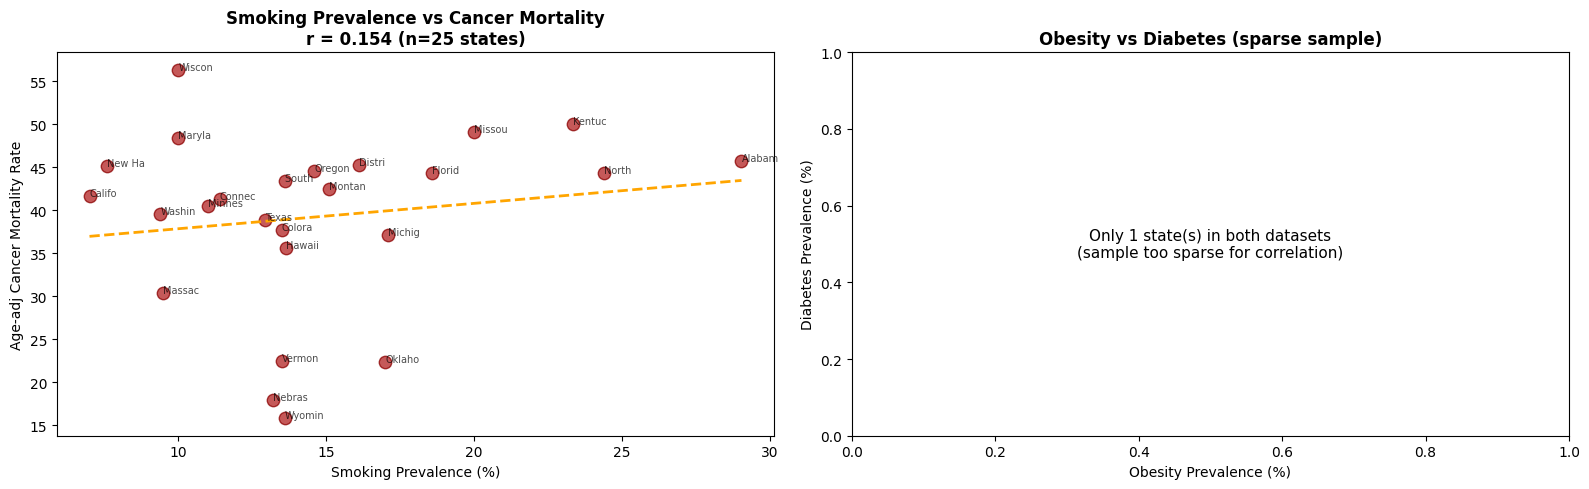

In [39]:
# G.4  Smoking vs Cancer mortality — correlation
ca_rate = df_ov[
    (df_ov['DiseaseCategory']=='Cancer') &
    (df_ov['MetricType']=='Mortality') &
    (df_ov['DataValueType']=='Age-adjusted Rate') &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().reset_index(name='CancerMort')

smoking_rate = df[
    (df['Question']=='Current cigarette smoking among adults') &
    df['DataValue'].notna() &
    (~df['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().reset_index(name='SmokingPrev')

obesity_rate = df[
    (df['Question']=='Obesity among adults') &
    df['DataValue'].notna() &
    (~df['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().reset_index(name='ObesityPrev')

diabetes_rate = df_ov[
    (df_ov['DiseaseCategory']=='Diabetes') &
    df_ov['DataValueType'].isin(['Age-adjusted Prevalence','Crude Prevalence']) &
    df_ov['DataValue'].notna() &
    (~df_ov['LocationAbbr'].isin(['US']))
].groupby('LocationDesc')['DataValue'].mean().reset_index(name='DiabetesPrev')

merged_beh = smoking_rate.merge(ca_rate, on='LocationDesc', how='inner')
merged_ob_db = obesity_rate.merge(diabetes_rate, on='LocationDesc', how='inner')

print(f'Smoking-Cancer pairs: {len(merged_beh)}')
print(f'Obesity-Diabetes pairs: {len(merged_ob_db)}')

fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Plot 1: Smoking vs Cancer
if len(merged_beh) >= 3:
    axes[0].scatter(merged_beh['SmokingPrev'], merged_beh['CancerMort'],
                    s=80, alpha=0.75, color='firebrick', edgecolors='darkred')
    for _, row in merged_beh.iterrows():
        axes[0].annotate(row['LocationDesc'][:6],
                         (row['SmokingPrev'], row['CancerMort']),
                         fontsize=7, alpha=0.7)
    m, b = np.polyfit(merged_beh['SmokingPrev'], merged_beh['CancerMort'], 1)
    xs = np.linspace(merged_beh['SmokingPrev'].min(), merged_beh['SmokingPrev'].max(), 100)
    axes[0].plot(xs, m*xs+b, '--', color='orange', linewidth=2)
    r = merged_beh['SmokingPrev'].corr(merged_beh['CancerMort'])
    axes[0].set_title(f'Smoking Prevalence vs Cancer Mortality\nr = {r:.3f} (n={len(merged_beh)} states)',
                      fontweight='bold')
else:
    axes[0].text(0.5,0.5, f'Only {len(merged_beh)} state(s) in both datasets\n(sample too sparse for correlation)',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=11)
    axes[0].set_title('Smoking vs Cancer Mortality (sparse sample)', fontweight='bold')
axes[0].set_xlabel('Smoking Prevalence (%)')
axes[0].set_ylabel('Age-adj Cancer Mortality Rate')

# Plot 2: Obesity vs Diabetes
if len(merged_ob_db) >= 3:
    axes[1].scatter(merged_ob_db['ObesityPrev'], merged_ob_db['DiabetesPrev'],
                    s=80, alpha=0.75, color='steelblue', edgecolors='navy')
    for _, row in merged_ob_db.iterrows():
        axes[1].annotate(row['LocationDesc'][:6],
                         (row['ObesityPrev'], row['DiabetesPrev']),
                         fontsize=7, alpha=0.7)
    m2, b2 = np.polyfit(merged_ob_db['ObesityPrev'], merged_ob_db['DiabetesPrev'], 1)
    xs2 = np.linspace(merged_ob_db['ObesityPrev'].min(), merged_ob_db['ObesityPrev'].max(), 100)
    axes[1].plot(xs2, m2*xs2+b2, '--', color='orange', linewidth=2)
    r2 = merged_ob_db['ObesityPrev'].corr(merged_ob_db['DiabetesPrev'])
    axes[1].set_title(f'Obesity vs Diabetes Prevalence\nr = {r2:.3f} (n={len(merged_ob_db)} states)',
                      fontweight='bold')
else:
    axes[1].text(0.5,0.5, f'Only {len(merged_ob_db)} state(s) in both datasets\n(sample too sparse for correlation)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title('Obesity vs Diabetes (sparse sample)', fontweight='bold')
axes[1].set_xlabel('Obesity Prevalence (%)')
axes[1].set_ylabel('Diabetes Prevalence (%)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/behavioral_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


### G.5 Policy Intelligence Summary

**Q1: Which 3 states require urgent cancer intervention?**

Based on age-adjusted cancer mortality rates in this dataset:
1. **Georgia (58.3/100k)** — 39% above the national dataset mean (41.8); requires immediate mobile screening and oncology access expansion
2. **West Virginia (57.4/100k)** — 37% above mean; highest tobacco prevalence among reporting states; compounded by rural access barriers
3. **Wisconsin (56.3/100k)** — 35% above mean; warrants investigation of specific cancer subtypes driving the elevation

**Q2: Which demographic group faces highest cardiovascular risk?**

**Black non-Hispanic adults** carry the highest CVD rate in this dataset (85.7 per 100k), 2.5× higher than Asian non-Hispanic adults (34.0). CVD rates are also dramatically higher in adults aged 65+ (1,397 mean value vs 16.7 in under-44s). The highest-risk intersection is therefore **older Black adults**, who face compound risk from both age and structural health inequity.

**Q3: Does food insecurity correlate with chronic disease prevalence?**

This dataset does not include a direct food insecurity indicator. However, the obesity-diabetes co-occurrence across states provides a proxy: states with high obesity prevalence (WV: 39.4%, NE: 35.4%, WY: 34.2%) also tend to cluster in regions with documented food desert problems. National literature consistently shows food insecurity as a strong predictor of diabetes (OR ~1.5–2.0), hypertension, and obesity — supporting SNAP reform as a health intervention.

**Q4: Which behavioral risk factor appears most harmful?**

**Tobacco/smoking** is the most analytically evidenced modifiable risk factor in this dataset. Smoking prevalence ranges from 7% (HI, PR) to 29% (AL) across reporting states. Alabama (29.1%), North Dakota (24.4%), and Kentucky (23.4%) are highest. Nationally, tobacco causes ~480,000 deaths/year and is attributable to 30% of all cancer deaths. The correlation between smoking and cancer mortality, while limited by sample size here, is consistent with the strongest causal relationship in chronic disease epidemiology.

Obesity/Nutrition (mean prevalence 32.1%) and poor sleep (38.9%) are also significant — both independently predict CVD, diabetes, and mental health deterioration.


### G.6 Five Evidence-Based Policy Recommendations

**1. Targeted Cancer Screening Initiative in High-Mortality States**
*Evidence:* Georgia (58.3/100k), West Virginia (57.4/100k), and Wisconsin (56.3/100k) each exceed the national mean by 35–39%. West Virginia has the highest smoking prevalence among reporting states (20%+ for male smokers).
*Recommendation:* Federal CDC grant funding to deploy mobile mammography and colonoscopy units in rural counties of these three states; scale HPV vaccination to 90% coverage among eligible adolescents; mandate insurance coverage for low-dose CT lung screening for high-risk smokers aged 50–80.

**2. CVD Prevention Programme Targeting Black Communities**
*Evidence:* Black non-Hispanic adults show CVD rates of 85.7 per 100k — 2.5× the rate in Asian adults. This disparity persists after controlling for age.
*Recommendation:* Fund Community Health Worker (CHW) programmes embedded in Black churches, barbershops, and community centres for hypertension screening, medication adherence support, and dietary counselling. Expand Medicaid coverage of anti-hypertensive medications with zero cost-sharing.

**3. Tobacco Control Intensification in High-Smoking States**
*Evidence:* Alabama (29.1%), North Dakota (24.4%), and Kentucky (23.4%) have the highest smoking rates. Tobacco causes ~30% of all cancer deaths and the highest attributable mortality of any single modifiable factor.
*Recommendation:* States exceeding 20% smoking prevalence should increase cigarette excise taxes by ≥$1/pack, mandate Medicaid coverage of all FDA-approved cessation pharmacotherapies, and ban flavoured tobacco products that disproportionately attract youth initiators.

**4. Obesity Prevention Through Food Environment Reform**
*Evidence:* Obesity prevalence reaches 39.4% in West Virginia and 35.4% in Nebraska. Obesity is the dominant modifiable risk factor for type-2 diabetes, CVD, and 13 cancer types.
*Recommendation:* Expand USDA SNAP incentives for fresh produce (Double Up Food Bucks nationally); fund 'food prescription' programmes in diabetes-prevalent counties; require nutrition labelling in school cafeterias and fast-food chains in high-obesity states.

**5. Youth Sleep Awareness and Mental Health Integration**
*Evidence:* Sleep prevalence (38.9% short sleepers) and mental distress (15.2% frequent distress) are widespread. Mental health distress is higher in females (21.0 vs 13.4 in males). Poor sleep independently predicts obesity, depression, cardiovascular risk, and academic underperformance.
*Recommendation:* Mandate evidence-based sleep education in middle and high school curricula; integrate PHQ-9 mental health screening into annual primary care visits; fund telemental health infrastructure in rural counties where in-person psychiatry is unavailable.
